In [6]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score

from xgboost import XGBRegressor

# 1️⃣ Chargement des données
X_train = pd.read_csv('../data/X_train_encoded.csv')
X_test = pd.read_csv('../data/X_test_encoded.csv')
y_train_log = pd.read_csv('../data/y_train_log.csv').squeeze()  # .squeeze() pour avoir une Series

# 2️⃣ Liste des 30 features communes détectées à l’étape précédente
selected_features = [
    'OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars',
    '1stFlrSF', 'BsmtFinSF1', 'YearBuilt', 'YearRemodAdd', 'GarageArea',
    'TotRmsAbvGrd', 'Fireplaces', 'MasVnrArea', 'LotArea', '2ndFlrSF',
    'FullBath', 'OpenPorchSF', 'HalfBath', 'WoodDeckSF', 'KitchenAbvGr',
    'GarageYrBlt', 'BsmtUnfSF', 'BedroomAbvGr', 'ScreenPorch', 'LotFrontage',
    'MoSold', 'MSSubClass_60', 'GarageFinish_Unf', 'KitchenQual_TA',
    'Neighborhood_NridgHt', 'BsmtQual_TA'
]

# 🔍 Vérification et filtrage des colonnes existantes
available_features = [col for col in selected_features if col in X_train.columns]
missing = [col for col in selected_features if col not in X_train.columns]
if missing:
    print("⚠️ Colonnes manquantes dans les données :", missing)

# 3️⃣ Sous-échantillonnage
X_train_sel = X_train[available_features]
X_test_sel = X_test[available_features]

# 4️⃣ Initialisation des modèles
models = {
    'LinearRegression': LinearRegression(),
    'Ridge (alpha=1)': Ridge(alpha=1.0),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
}

# 5️⃣ Validation croisée
for name, model in models.items():
    scores = cross_val_score(model, X_train_sel, y_train_log, cv=5, scoring='neg_root_mean_squared_error')
    print(f"{name} | RMSE moyen : {-scores.mean():.4f}")

# 6️⃣ Choix du modèle final et prédiction
final_model = models['XGBoost']
final_model.fit(X_train_sel, y_train_log)
y_pred_log = final_model.predict(X_test_sel)

# 7️⃣ Inverse de la transformation log
y_pred = np.expm1(y_pred_log)

# 8️⃣ Export du fichier de soumission
submission = pd.DataFrame({
    'Id': pd.read_csv('../data/test.csv')['Id'],
    'SalePrice': y_pred
})
submission.to_csv('submission.csv', index=False)
print("✅ Fichier 'submission.csv' sauvegardé.")


⚠️ Colonnes manquantes dans les données : ['MSSubClass_60']
LinearRegression | RMSE moyen : 0.1627
Ridge (alpha=1) | RMSE moyen : 0.1626
XGBoost | RMSE moyen : 0.1405
✅ Fichier 'submission.csv' sauvegardé.


In [7]:
# Phase 5 - Optimisation d'hyperparamètres (HPO) avec Optuna sur Ridge, Lasso, XGBoost

import pandas as pd
import numpy as np
import optuna

from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor

# Chargement des données
X = pd.read_csv('../data/X_train_encoded.csv')
y = pd.read_csv('../data/y_train_log.csv').squeeze()

# Sélection des features utilisées (tu peux les ajuster si besoin)
selected_features = [
    'OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars',
    '1stFlrSF', 'BsmtFinSF1', 'YearBuilt', 'YearRemodAdd', 'GarageArea',
    'TotRmsAbvGrd', 'Fireplaces', 'MasVnrArea', 'LotArea', '2ndFlrSF',
    'FullBath', 'OpenPorchSF', 'HalfBath', 'WoodDeckSF', 'KitchenAbvGr',
    'GarageYrBlt', 'BsmtUnfSF', 'BedroomAbvGr', 'ScreenPorch', 'LotFrontage',
    'MoSold', 'KitchenQual_TA', 'Neighborhood_NridgHt', 'BsmtQual_TA'
]
available_features = [col for col in selected_features if col in X.columns]
X = X[available_features]

# Fonction d'objectif pour Ridge
def objective_ridge(trial):
    alpha = trial.suggest_float("alpha", 0.001, 100.0, log=True)
    model = Ridge(alpha=alpha)
    score = cross_val_score(model, X, y, cv=5, scoring="neg_root_mean_squared_error").mean()
    return -score

# Fonction d'objectif pour Lasso
def objective_lasso(trial):
    alpha = trial.suggest_float("alpha", 0.0001, 10.0, log=True)
    model = Lasso(alpha=alpha, max_iter=10000)
    score = cross_val_score(model, X, y, cv=5, scoring="neg_root_mean_squared_error").mean()
    return -score

# Fonction d'objectif pour XGBoost
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state': 42
    }
    model = XGBRegressor(**params)
    score = cross_val_score(model, X, y, cv=5, scoring='neg_root_mean_squared_error').mean()
    return -score

# Lancement des optimisations
print("\n🔧 Optimisation Ridge")
study_ridge = optuna.create_study(direction="minimize")
study_ridge.optimize(objective_ridge, n_trials=30)
print("Best params Ridge:", study_ridge.best_params)

print("\n🔧 Optimisation Lasso")
study_lasso = optuna.create_study(direction="minimize")
study_lasso.optimize(objective_lasso, n_trials=30)
print("Best params Lasso:", study_lasso.best_params)

print("\n🔧 Optimisation XGBoost")
study_xgb = optuna.create_study(direction="minimize")
study_xgb.optimize(objective_xgb, n_trials=30)
print("Best params XGBoost:", study_xgb.best_params)

# Comparaison des meilleurs scores
print("\n📊 Résultats finaux :")
print(f"Ridge RMSE : {study_ridge.best_value:.4f}")
print(f"Lasso RMSE : {study_lasso.best_value:.4f}")
print(f"XGBoost RMSE : {study_xgb.best_value:.4f}")


[I 2025-04-30 19:05:49,482] A new study created in memory with name: no-name-079ac532-2603-4073-b45c-bb00905b223a
[I 2025-04-30 19:05:49,492] Trial 0 finished with value: 0.16284840194051423 and parameters: {'alpha': 0.03309036263476997}. Best is trial 0 with value: 0.16284840194051423.
[I 2025-04-30 19:05:49,501] Trial 1 finished with value: 0.16279490468313487 and parameters: {'alpha': 2.716811454785778}. Best is trial 1 with value: 0.16279490468313487.
[I 2025-04-30 19:05:49,509] Trial 2 finished with value: 0.16276596525406167 and parameters: {'alpha': 4.737930685995919}. Best is trial 2 with value: 0.16276596525406167.
[I 2025-04-30 19:05:49,516] Trial 3 finished with value: 0.16284286285544008 and parameters: {'alpha': 0.27006260430344103}. Best is trial 2 with value: 0.16276596525406167.
[I 2025-04-30 19:05:49,523] Trial 4 finished with value: 0.16278620149009898 and parameters: {'alpha': 3.2651637631641584}. Best is trial 2 with value: 0.16276596525406167.
[I 2025-04-30 19:05:4


🔧 Optimisation Ridge


[I 2025-04-30 19:05:49,585] Trial 12 finished with value: 0.16302296296504157 and parameters: {'alpha': 64.14394440770872}. Best is trial 5 with value: 0.16274017371621036.
[I 2025-04-30 19:05:49,595] Trial 13 finished with value: 0.16271084654887077 and parameters: {'alpha': 15.767675671113773}. Best is trial 13 with value: 0.16271084654887077.
[I 2025-04-30 19:05:49,604] Trial 14 finished with value: 0.16271166810783963 and parameters: {'alpha': 13.99654563924907}. Best is trial 13 with value: 0.16271084654887077.
[I 2025-04-30 19:05:49,612] Trial 15 finished with value: 0.16271205600936833 and parameters: {'alpha': 17.538395269179475}. Best is trial 13 with value: 0.16271084654887077.
[I 2025-04-30 19:05:49,620] Trial 16 finished with value: 0.16283570782701456 and parameters: {'alpha': 0.5876349669847352}. Best is trial 13 with value: 0.16271084654887077.
[I 2025-04-30 19:05:49,629] Trial 17 finished with value: 0.16284472309467138 and parameters: {'alpha': 0.18964569318907645}. Be

Best params Ridge: {'alpha': 15.767675671113773}

🔧 Optimisation Lasso


[I 2025-04-30 19:05:49,935] Trial 3 finished with value: 0.16798068357997137 and parameters: {'alpha': 0.014388735157067763}. Best is trial 2 with value: 0.16320438018279662.
[I 2025-04-30 19:05:49,969] Trial 4 finished with value: 0.20111350220239127 and parameters: {'alpha': 1.2155305593660735}. Best is trial 2 with value: 0.16320438018279662.
[I 2025-04-30 19:05:50,075] Trial 5 finished with value: 0.16287459100179058 and parameters: {'alpha': 0.00039596953537517706}. Best is trial 5 with value: 0.16287459100179058.
[I 2025-04-30 19:05:50,135] Trial 6 finished with value: 0.1719284233518906 and parameters: {'alpha': 0.03211804429982488}. Best is trial 5 with value: 0.16287459100179058.
[I 2025-04-30 19:05:50,238] Trial 7 finished with value: 0.16286563287571065 and parameters: {'alpha': 0.0003606907629418934}. Best is trial 7 with value: 0.16286563287571065.
[I 2025-04-30 19:05:50,333] Trial 8 finished with value: 0.16303387296704752 and parameters: {'alpha': 0.0007965894850288269}.

Best params Lasso: {'alpha': 0.00010045922666366625}

🔧 Optimisation XGBoost


[I 2025-04-30 19:05:55,875] Trial 0 finished with value: 0.14903376977389332 and parameters: {'n_estimators': 781, 'max_depth': 10, 'learning_rate': 0.1258464332326675, 'subsample': 0.705980594494229, 'colsample_bytree': 0.5632654342794114}. Best is trial 0 with value: 0.14903376977389332.
[I 2025-04-30 19:05:56,649] Trial 1 finished with value: 0.14699276682003473 and parameters: {'n_estimators': 105, 'max_depth': 8, 'learning_rate': 0.09943885708201564, 'subsample': 0.503667194927439, 'colsample_bytree': 0.8164477564547593}. Best is trial 1 with value: 0.14699276682003473.
[I 2025-04-30 19:05:59,447] Trial 2 finished with value: 0.15857601714015224 and parameters: {'n_estimators': 968, 'max_depth': 6, 'learning_rate': 0.28580181835372276, 'subsample': 0.5924510667918328, 'colsample_bytree': 0.9846149812187504}. Best is trial 1 with value: 0.14699276682003473.
[I 2025-04-30 19:06:01,954] Trial 3 finished with value: 0.1540798609650267 and parameters: {'n_estimators': 642, 'max_depth':

Best params XGBoost: {'n_estimators': 553, 'max_depth': 3, 'learning_rate': 0.06132594630130065, 'subsample': 0.7776124021727523, 'colsample_bytree': 0.6915649372499099}

📊 Résultats finaux :
Ridge RMSE : 0.1627
Lasso RMSE : 0.1628
XGBoost RMSE : 0.1393


/var/folders/4b/chfw46mj63v9swn5g8b6ygdw0000gn/T/ipykernel_19570/2180058570.py:6: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study_ridge)


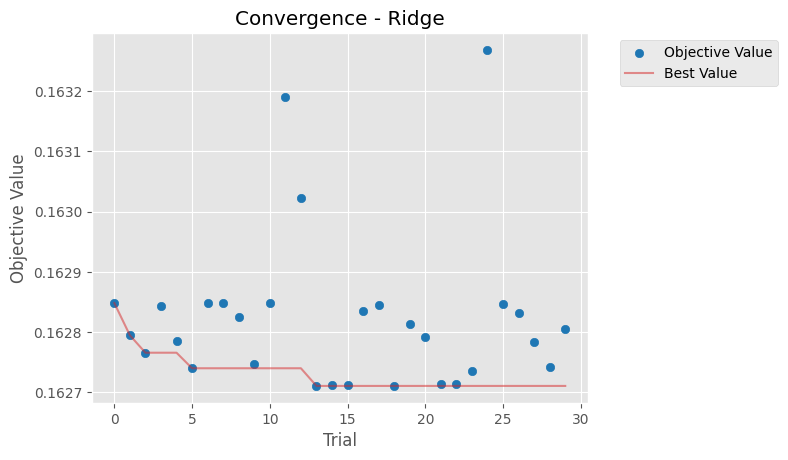

/var/folders/4b/chfw46mj63v9swn5g8b6ygdw0000gn/T/ipykernel_19570/2180058570.py:11: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study_lasso)


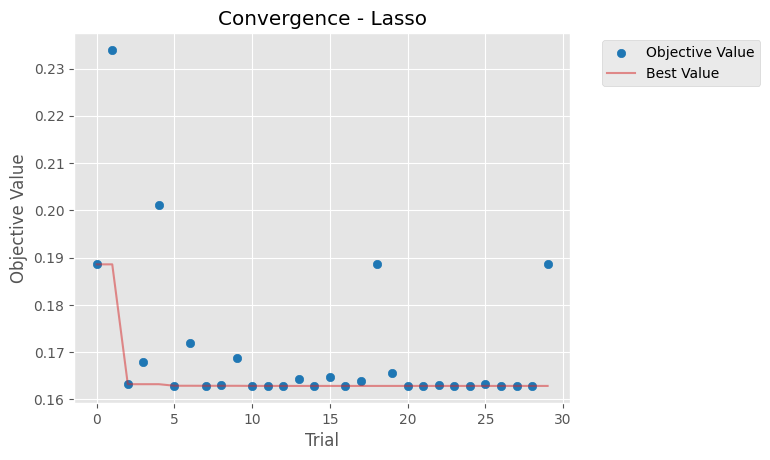

/var/folders/4b/chfw46mj63v9swn5g8b6ygdw0000gn/T/ipykernel_19570/2180058570.py:16: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study_xgb)


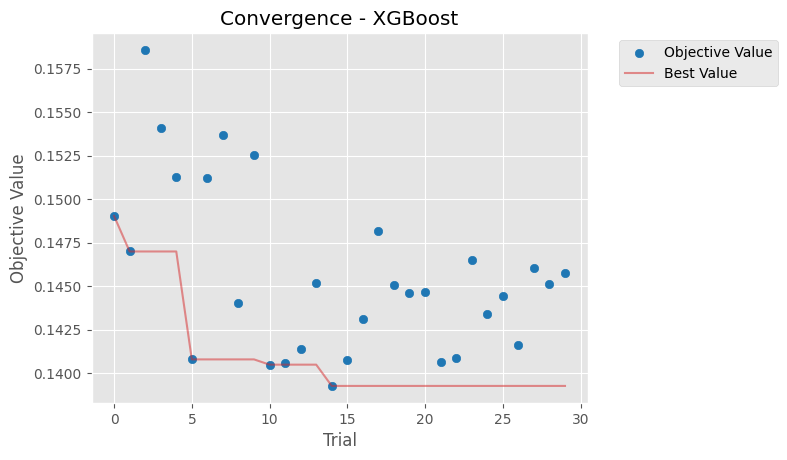

In [8]:
import optuna
import matplotlib.pyplot as plt
from optuna.visualization.matplotlib import plot_optimization_history

# Affiche la courbe pour Ridge
plot_optimization_history(study_ridge)
plt.title("Convergence - Ridge")
plt.show()

# Pour Lasso
plot_optimization_history(study_lasso)
plt.title("Convergence - Lasso")
plt.show()

# Pour XGBoost
plot_optimization_history(study_xgb)
plt.title("Convergence - XGBoost")
plt.show()


In [19]:
import pandas as pd
import numpy as np

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import StackingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor

# 🔹 Chargement des données
X_train = pd.read_csv('../Data/X_train_encoded.csv')
X_test = pd.read_csv('../Data/X_test_encoded.csv')
y_train_log = pd.read_csv('../Data/y_train_log.csv').squeeze()
test_ids = pd.read_csv('../Data/test.csv')['Id']

# 🔹 Sélection des variables
selected_features = [
    'OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars',
    '1stFlrSF', 'BsmtFinSF1', 'YearBuilt', 'YearRemodAdd', 'GarageArea',
    'TotRmsAbvGrd', 'Fireplaces', 'MasVnrArea', 'LotArea', '2ndFlrSF',
    'FullBath', 'OpenPorchSF', 'HalfBath', 'WoodDeckSF', 'KitchenAbvGr',
    'GarageYrBlt', 'BsmtUnfSF', 'BedroomAbvGr', 'ScreenPorch', 'LotFrontage',
    'MoSold', 'GarageFinish_Unf', 'KitchenQual_TA',
    'Neighborhood_NridgHt', 'BsmtQual_TA'
]

X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

# 🔹 Meilleurs modèles trouvés via Optuna (avec Pipeline)
ridge_best = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=15.47))
])

lasso_best = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=0.000106, max_iter=5000))  # max_iter pour éviter le warning
])

xgb_best = XGBRegressor(
    n_estimators=659,
    max_depth=5,
    learning_rate=0.0101,
    subsample=0.518,
    colsample_bytree=0.817,
    random_state=42,
    verbosity=0
)

# 🔹 Stacking
stacked_model = StackingRegressor(
    estimators=[
        ('ridge', ridge_best),
        ('lasso', lasso_best),
        ('xgb', xgb_best)
    ],
    final_estimator=Ridge(alpha=1.0),
    passthrough=False,
    cv=5,
    n_jobs=-1
)

# 🔹 Évaluation
scores = cross_val_score(stacked_model, X_train_sel, y_train_log, cv=5, scoring='neg_root_mean_squared_error')
print(f"📊 Stacking RMSE moyen : {-scores.mean():.4f}")

# 🔹 Entraînement final et prédictions
stacked_model.fit(X_train_sel, y_train_log)
y_pred_log = stacked_model.predict(X_test_sel)
y_pred = np.expm1(y_pred_log)

# 🔹 Export
submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': y_pred
})
submission.to_csv('submission_stacking.csv', index=False)
print("✅ Fichier 'submission_stacking.csv' sauvegardé.")


📊 Stacking RMSE moyen : 0.1405
✅ Fichier 'submission_stacking.csv' sauvegardé.
